In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add module directory to path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from utils.plots import calculate_accuracy, plot_confusion_matrices, plot_distributions, plot_accuracy, plot_metric_heatmap, plot_precision_recall_curves, plot_cooccurrence, plot_error_distribution, GT_COLS, PRED_COLS, LABELS

In [12]:
csvs = [
    ("./outputs/results/batch_16760089_result.csv", "Qwen no explanation"), # Generated without explanation output
    ("./outputs/results/batch_16760618_result.csv", "Qwen with explanation"), # Generated with explanation output
    ("./outputs/results/batch_16772875_result.csv", "Qwen 5 random"), # Used 5 random demonstrations
    ("./outputs/results/batch_16773201_result.csv", "Qwen 5 fixed"), # 5 Fixed demos with different label combinations
]

[<Figure size 1600x600 with 6 Axes>,
 <Figure size 1600x600 with 6 Axes>,
 <Figure size 1600x600 with 6 Axes>,
 <Figure size 1600x600 with 6 Axes>]

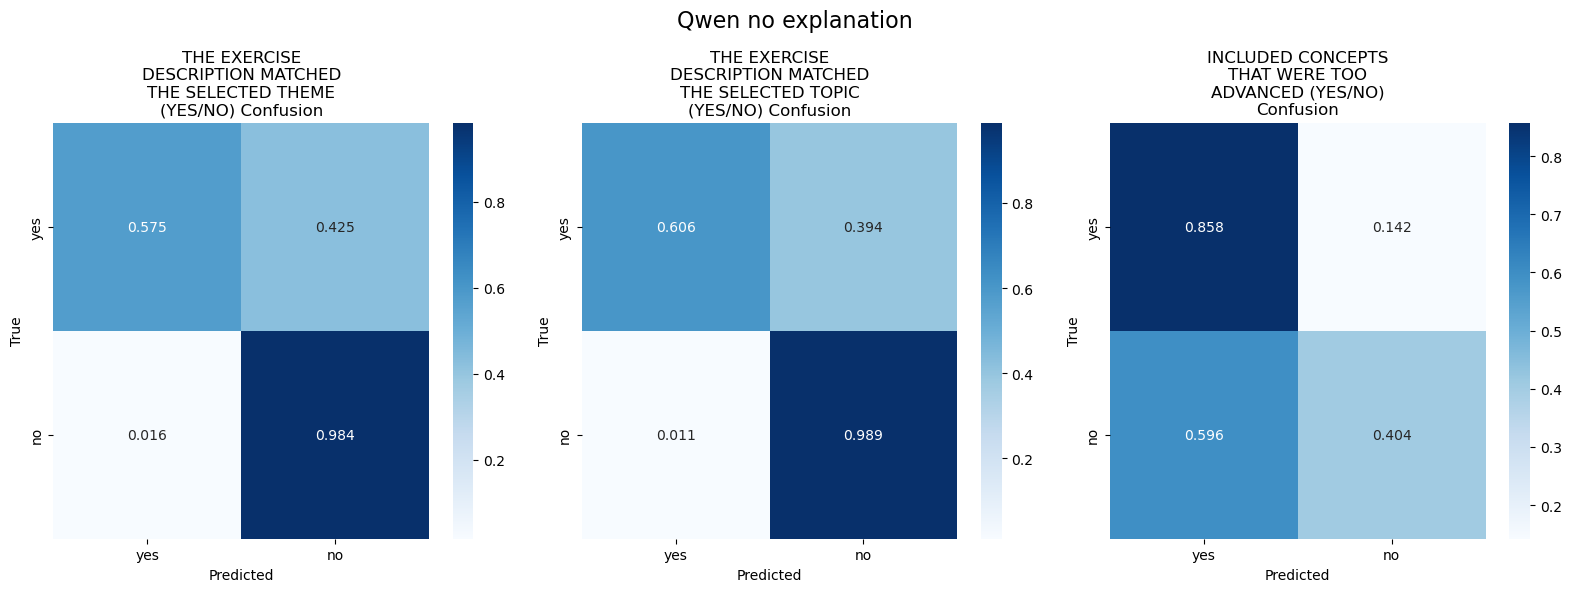

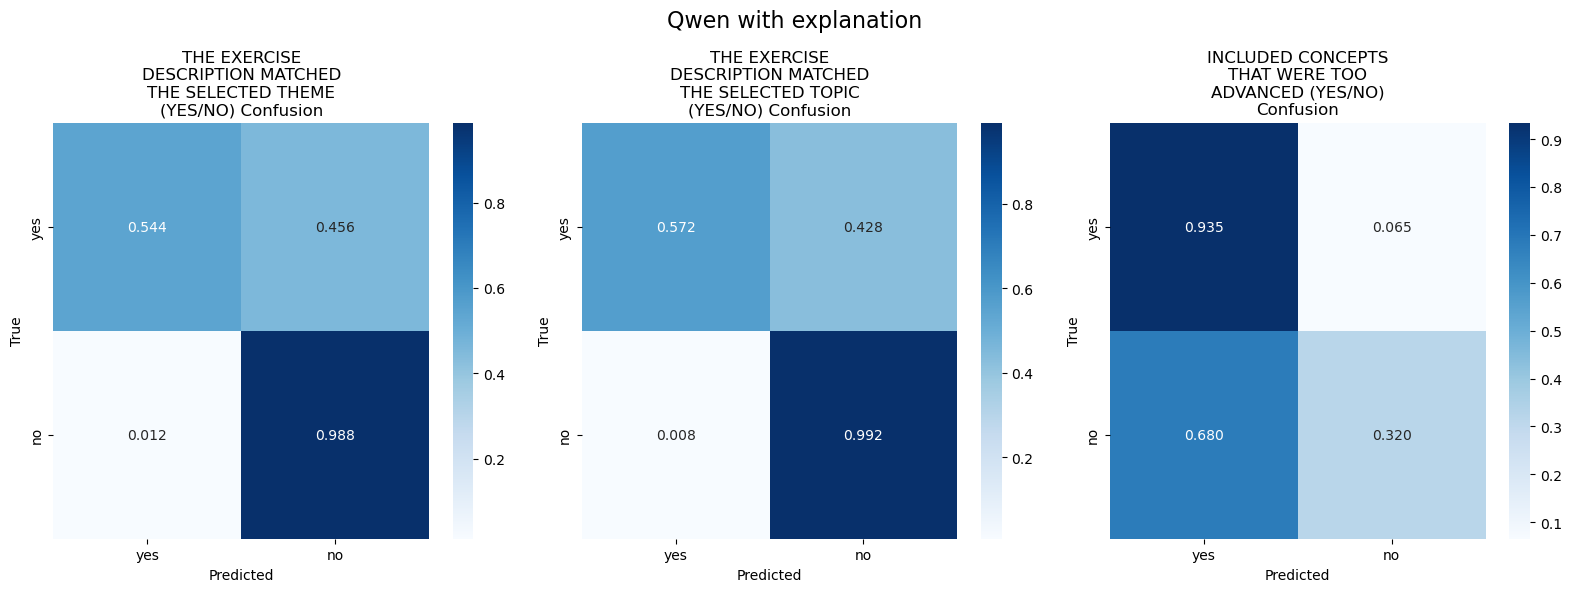

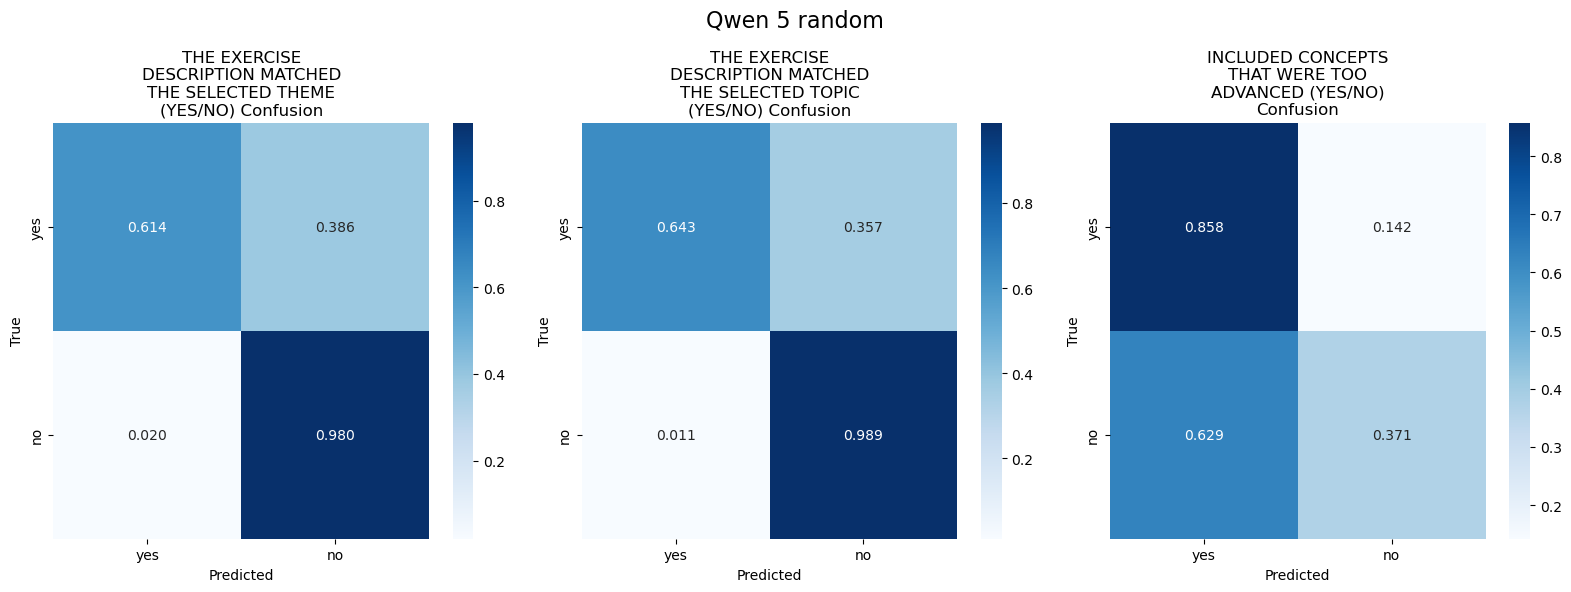

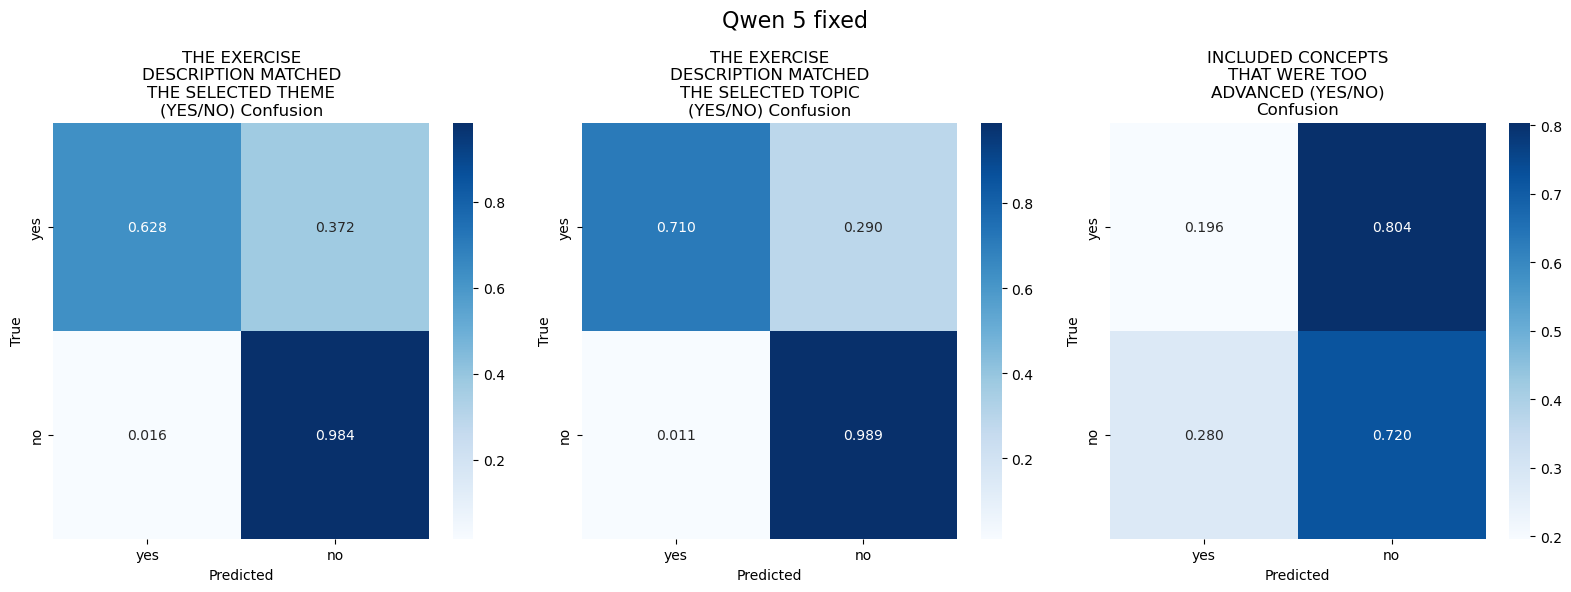

In [20]:
def build_figure_for_csv(csvs,
                         labels=LABELS,
                         cols1=GT_COLS,
                         cols2=PRED_COLS,
                         conf=True, acc=True, dist=True):

    filepath, model = csvs
    
    df = pd.read_csv(filepath, sep=";")

    # Layout:
    # Row 0: confusion matrices (3 plots)
    # Row 1: accuracy (1 plot spanning all columns)
    # Row 2-4: distributions (3 rows x 2 columns)

    num_rows = 0
    if conf:
        num_rows += 1
    if acc:
        num_rows += 1
    if dist:
        num_rows += 3

    fig = plt.figure(figsize=(16, num_rows * 6))
    gs = fig.add_gridspec(num_rows, 3)

    # --- Confusion matrices ---
    if conf:
        cm_axes = [
            fig.add_subplot(gs[0, i]) for i in range(3)
        ]
        plot_confusion_matrices(df, cm_axes, labels, cols1, cols2)

    # --- Accuracy (span full width) ---
    if acc:
        acc_ax = fig.add_subplot(gs[1 if conf else 0, :])
        plot_accuracy(df, acc_ax, cols1, cols2)

    # --- Distributions ---
    if dist:
        dist_axes = [
            [fig.add_subplot(gs[num_rows - 3 + i, 0]),
             fig.add_subplot(gs[num_rows - 3 + i, 1])]
            for i in range(len(cols1))
        ]
    
        plot_distributions(df,
                           pd.DataFrame(dist_axes).values,
                           labels,
                           cols1, cols2)

    fig.suptitle(model, fontsize=16)
    fig.tight_layout()

    return fig


def run_on_csvs(csv_paths, conf=True, acc=True, dist=True):
    figs = []

    for path in csv_paths:
        fig = build_figure_for_csv(path, conf=conf, acc=acc, dist=dist)
        figs.append(fig)

    return figs

run_on_csvs(csvs, acc=False, dist=False)

In [4]:
df0 = pd.read_csv(csvs[0], sep=";")
df1 = pd.read_csv(csvs[1], sep=";")
df2 = pd.read_csv(csvs[2], sep=";")
df3 = pd.read_csv(csvs[3], sep=";")

for df in [df0, df1, df2, df3]:
    print(calculate_accuracy(df)) # Dataframe contains gt and preds

{'theme_accuracy': np.float64(0.7663551401869159), 'topic_accuracy': np.float64(0.7962616822429907), 'concept_accuracy': np.float64(0.37570093457943926), 'total_accuracy': np.float64(0.308411214953271)}
{'theme_accuracy': np.float64(0.7514018691588785), 'topic_accuracy': np.float64(0.7813084112149533), 'concept_accuracy': np.float64(0.3813084112149533), 'total_accuracy': np.float64(0.33457943925233646)}
{'theme_accuracy': np.float64(0.7850467289719626), 'topic_accuracy': np.float64(0.8149532710280374), 'concept_accuracy': np.float64(0.3925233644859813), 'total_accuracy': np.float64(0.32710280373831774)}
{'theme_accuracy': np.float64(0.794392523364486), 'topic_accuracy': np.float64(0.8485981308411215), 'concept_accuracy': np.float64(0.5345794392523364), 'total_accuracy': np.float64(0.35700934579439253)}


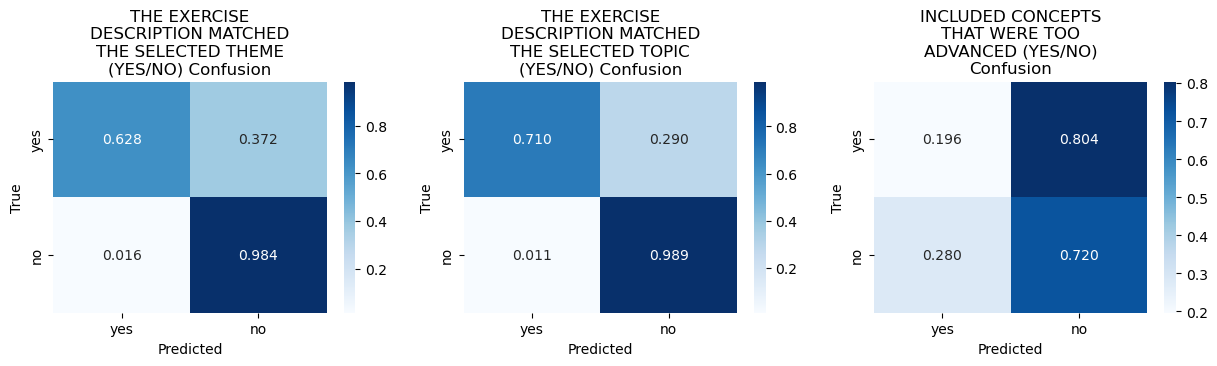

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
plot_confusion_matrices(df, axes)
plt.show()

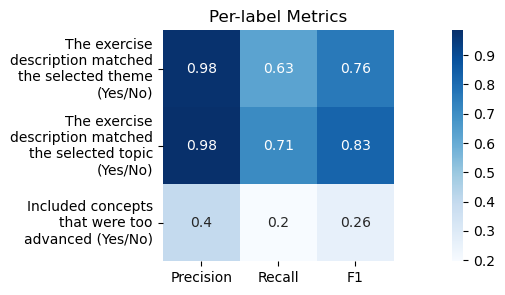

In [6]:
fig, axes = plt.subplots(1, figsize=(15, 3))
plot_metric_heatmap(df, axes)
plt.show()

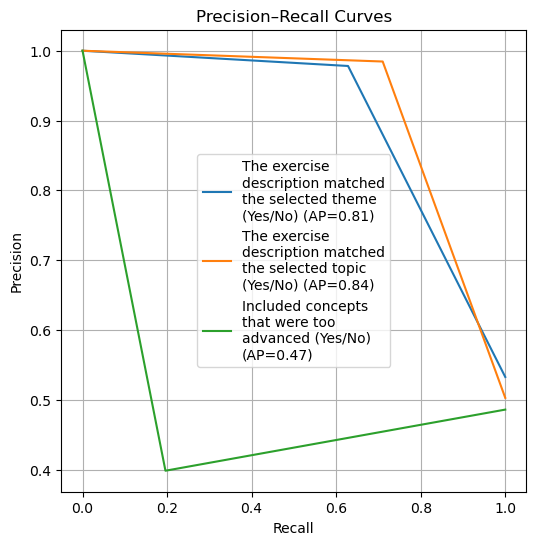

In [7]:
fig, axes = plt.subplots(1, figsize=(6, 6))
plot_precision_recall_curves(df, axes)
plt.show()

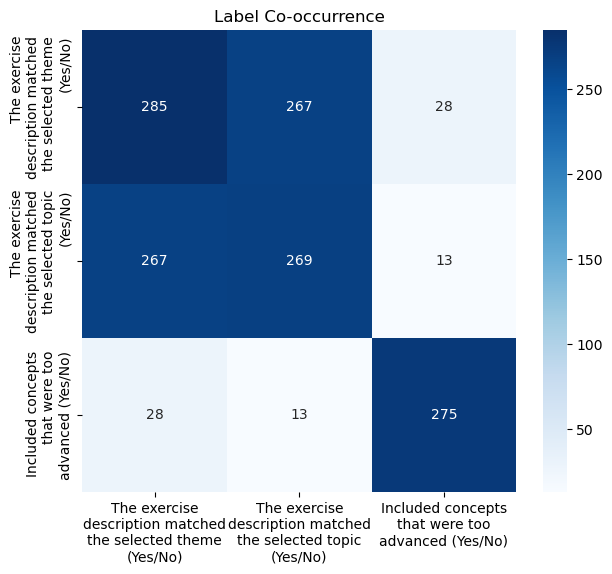

In [8]:
fig, axes = plt.subplots(1, figsize=(7, 6))
plot_cooccurrence(df, axes)
plt.show()

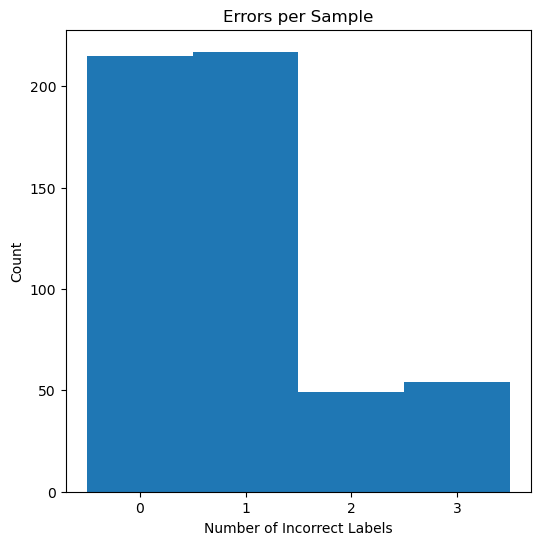

In [9]:
fig, axes = plt.subplots(1, figsize=(6, 6))
plot_error_distribution(df, axes)
plt.show()

/home/kaariaa3/mscthesis/src/utils/plots.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([wrap_text(col1, 20) for col1 in cols1])


AttributeError: 'numpy.ndarray' object has no attribute 'figure'

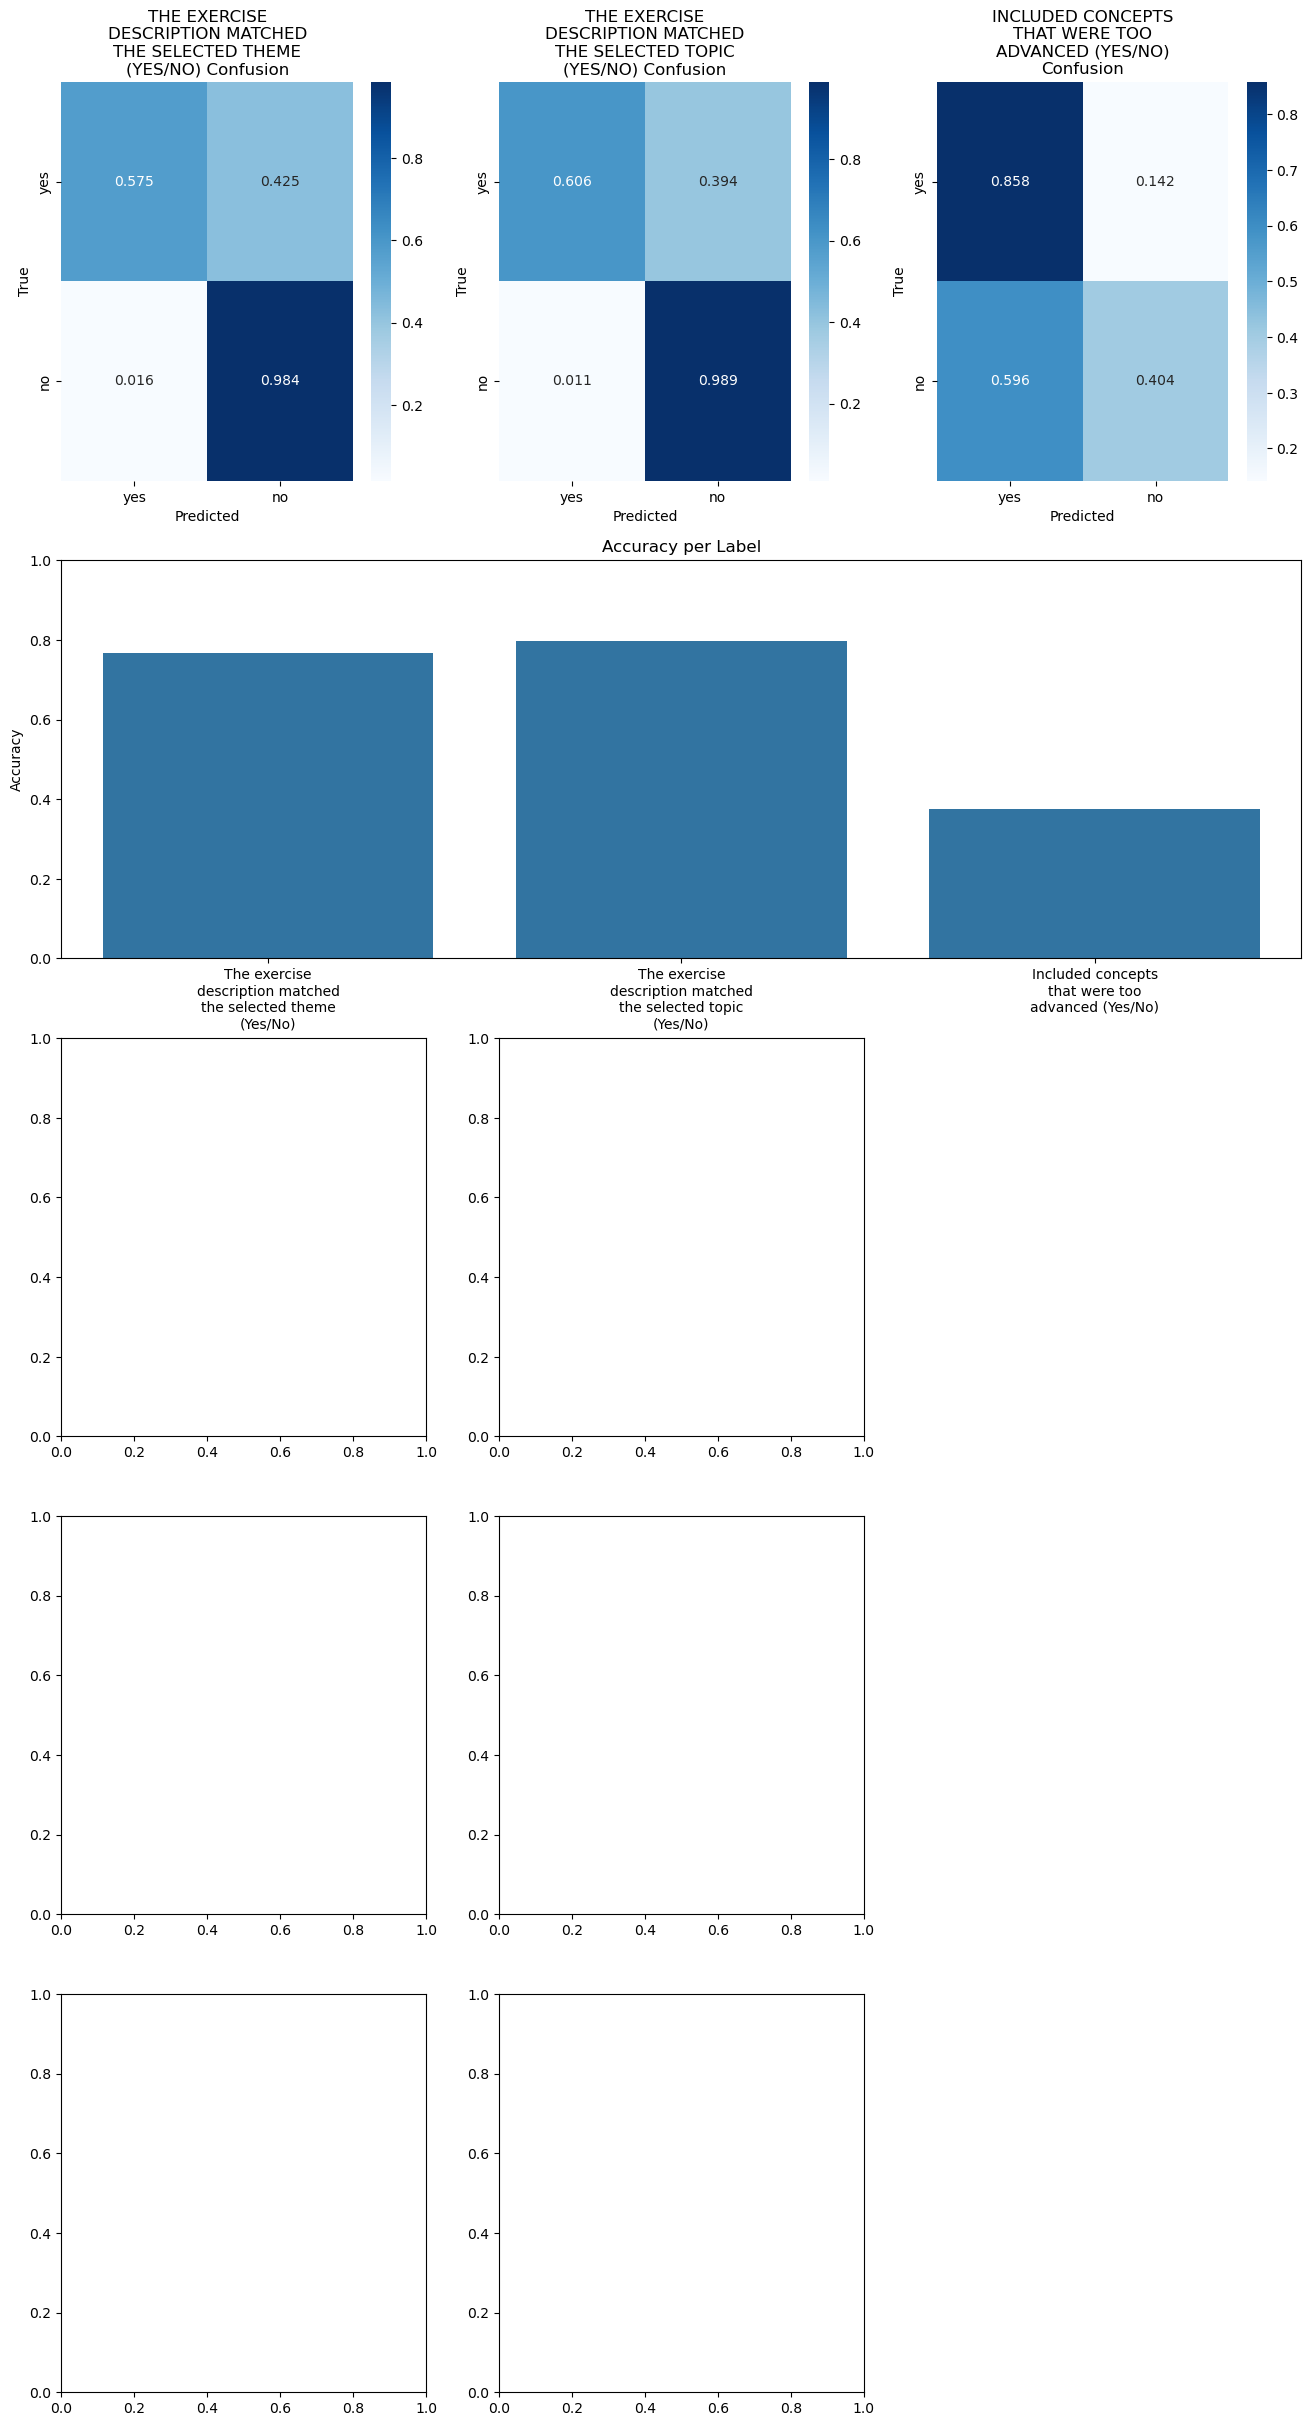

In [15]:
run_on_csvs(csvs)